In [1]:
# IMPORT SETTINGS
# Append the pipelining/src directory so that config.py and utils.py are importable
# without installing them as a package. This keeps the project self-contained.

import sys
sys.path.append(r'C:\traffic-demand-final\pipelining\src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from config import *

# Seaborn style and palette applied globally so every downstream plot
# inherits a consistent look without repeated configuration.
sns.set_style('whitegrid')
sns.set_palette('Blues_d')
plt.rcParams.update({'font.size': 12})

# PLOT_SAVE points to the univariate subfolder defined in config.
# All raw-data plots belong here because they describe individual variables
# before any relationship analysis takes place.
PLOT_SAVE = UNIVARIATE_PLOTS_DIR

In [2]:
# CELL 1 — Load and preview the data

df = pd.read_csv(TRAIN_FILE)

print(f"Rows: {df.shape[0]:,}    Columns: {df.shape[1]}")

df.head(10)

Rows: 77,299    Columns: 11


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
5,5,qp02zw,48,0:0,0.016262,Residential,2,Not Allowed,Yes,8.446025,Rainy
6,6,qp02zy,48,0:0,0.042247,Residential,3,Allowed,Yes,15.772408,Foggy
7,7,qp08by,48,0:0,0.040135,Residential,1,Not Allowed,No,2.705143,Snowy
8,8,qp08gq,48,0:0,0.001002,Residential,1,Not Allowed,No,18.136899,Foggy
9,9,qp08gy,48,0:0,0.003948,Residential,3,Allowed,Yes,12.738209,Rainy


In [3]:
# CELL 2 — Data types and null summary table
# This table gives a full picture of the data before any preprocessing begins.
# Knowing exactly which columns carry nulls and in what proportion drives
# every imputation decision that follows.

summary = pd.DataFrame({
    'dtype':       df.dtypes,
    'non_null':    df.notnull().sum(),
    'null_count':  df.isnull().sum(),
    'null_pct':    (df.isnull().sum() / len(df) * 100).round(2),
    'unique_vals': df.nunique()
})

summary

,dtype,non_null,null_count,null_pct,unique_vals
Index,int64,77299,0,0.00,77299
geohash,str,77299,0,0.00,1249
day,int64,77299,0,0.00,2
timestamp,str,77299,0,0.00,96
demand,float64,77299,0,0.00,76715
RoadType,str,76699,600,0.78,3
NumberofLanes,int64,77299,0,0.00,5
LargeVehicles,str,77299,0,0.00,2
Landmarks,str,77299,0,0.00,2
Temperature,float64,74804,2495,3.23,74804


In [4]:
# CELL 3 — Basic statistics
# include='all' ensures categorical columns also appear in the summary,
# so we can see top values and frequency counts alongside numeric quartiles.

df.describe(include='all')

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
count,77299.000000,77299,77299.000000,77299,7.729900e+04,76699,77299.000000,77299,77299,74804.000000,76502
unique,NaN,1249,NaN,96,NaN,3,NaN,2,2,NaN,4
top,NaN,qp094q,NaN,2:0,NaN,Residential,NaN,Not Allowed,Yes,NaN,Sunny
freq,NaN,105,NaN,1778,NaN,69230,NaN,50673,52042,NaN,27717
mean,38649.000000,NaN,48.101838,NaN,9.394238e-02,NaN,2.014334,NaN,NaN,16.405354,NaN
std,22314.443566,NaN,0.302438,NaN,1.421905e-01,NaN,0.904665,NaN,NaN,7.359835,NaN
min,0.000000,NaN,48.000000,NaN,6.245650e-07,NaN,1.000000,NaN,NaN,-14.935097,NaN
25%,19324.500000,NaN,48.000000,NaN,1.822723e-02,NaN,1.000000,NaN,NaN,11.430473,NaN
50%,38649.000000,NaN,48.000000,NaN,4.775994e-02,NaN,2.000000,NaN,NaN,16.382587,NaN
75%,57973.500000,NaN,48.000000,NaN,1.085951e-01,NaN,3.000000,NaN,NaN,21.298833,NaN


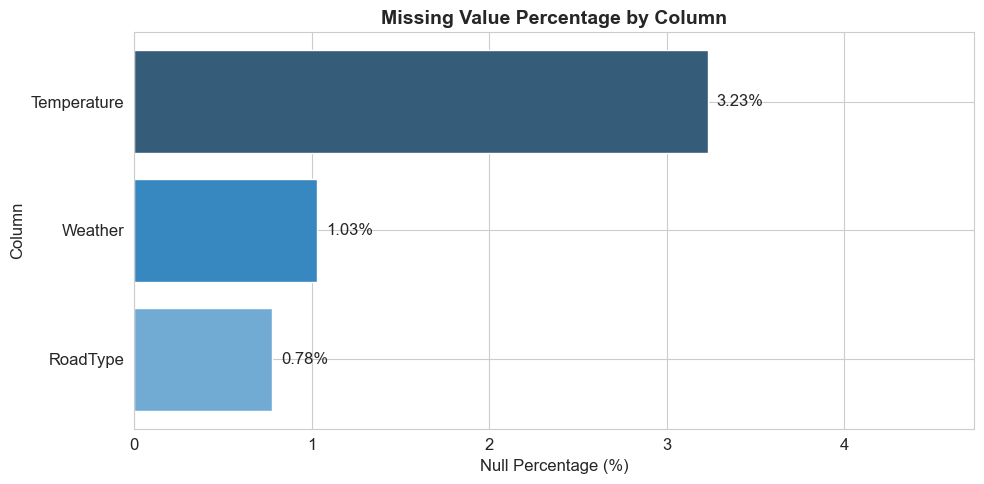

In [5]:
# CELL 4 — Missing value bar chart
# Only columns with at least one null are plotted.
# Restricting to these columns prevents the chart from being cluttered
# with zero-null bars that carry no useful information.

null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_pct = null_pct[null_pct > 0].sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

palette = sns.color_palette('Blues_d', len(null_pct))
bars = ax.barh(null_pct.index, null_pct.values, color=palette)

# Label each bar with its exact percentage so the reader does not have to
# estimate from the axis ticks.
for bar, val in zip(bars, null_pct.values):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.2f}%',
        va='center',
        ha='left',
        fontsize=12
    )

ax.set_title('Missing Value Percentage by Column', fontsize=14, fontweight='bold')
ax.set_xlabel('Null Percentage (%)', fontsize=12)
ax.set_ylabel('Column', fontsize=12)
ax.set_xlim(0, null_pct.max() + 1.5)

plt.tight_layout()
plt.savefig(f'{PLOT_SAVE}/missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# CELL 5 — Unique value counts per column
# geohash will have a very high unique count (1,249 distinct location cells).
# This is exactly why target encoding is needed instead of one-hot encoding:
# one-hot encoding would create 1,249 binary columns, making the feature
# matrix sparse, memory-heavy, and prone to the curse of dimensionality.

max_col_len = max(len(c) for c in df.columns)
for col in df.columns:
    print(f"  {col:<{max_col_len}}  ->  {df[col].nunique():>6,} unique values")

  Index          ->  77,299 unique values
  geohash        ->   1,249 unique values
  day            ->       2 unique values
  timestamp      ->      96 unique values
  demand         ->  76,715 unique values
  RoadType       ->       3 unique values
  NumberofLanes  ->       5 unique values
  LargeVehicles  ->       2 unique values
  Landmarks      ->       2 unique values
  Temperature    ->  74,804 unique values
  Weather        ->       4 unique values


In [1]:
import pandas as pd
df = pd.read_csv(r"C:\traffic-demand-final\DATASETS\train.csv")
print(df.head(3).to_string())
print("\nColumns:", df.columns.tolist())

   Index geohash  day timestamp    demand     RoadType  NumberofLanes LargeVehicles Landmarks  Temperature Weather
0      0  qp02z1   48       0:0  0.048804          NaN              1   Not Allowed        No          NaN     NaN
1      1  qp02zt   48       0:0  0.118507  Residential              3       Allowed       Yes    31.104565   Sunny
2      2  qp08bj   48       0:0  0.027132  Residential              1   Not Allowed        No    25.919267   Sunny

Columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather']


In [7]:
# CELL 6 — Categorical value counts
# Printing value counts for each low-cardinality categorical column gives
# an immediate sense of class balance, which matters for encoding strategy
# and for spotting any rare categories that might need grouping.

cat_cols = ['RoadType', 'Weather', 'LargeVehicles', 'Landmarks']

for col in cat_cols:
    print(f"{'─' * 40}")
    print(f"  {col}")
    print(f"{'─' * 40}")
    vc = df[col].value_counts(dropna=False)
    for label, count in vc.items():
        pct = count / len(df) * 100
        print(f"  {str(label):<20}  {count:>6,}  ({pct:.1f}%)")
    print()

────────────────────────────────────────
  RoadType
────────────────────────────────────────
  Residential           69,230  (89.6%)
  Street                 3,909  (5.1%)
  Highway                3,560  (4.6%)
  nan                      600  (0.8%)

────────────────────────────────────────
  Weather
────────────────────────────────────────
  Sunny                 27,717  (35.9%)
  Rainy                 20,824  (26.9%)
  Foggy                 20,243  (26.2%)
  Snowy                  7,718  (10.0%)
  nan                      797  (1.0%)

────────────────────────────────────────
  LargeVehicles
────────────────────────────────────────
  Not Allowed           50,673  (65.6%)
  Allowed               26,626  (34.4%)

────────────────────────────────────────
  Landmarks
────────────────────────────────────────
  Yes                   52,042  (67.3%)
  No                    25,257  (32.7%)



## Raw Data — Key Observations

- The training set has **77,299 rows and 11 columns** — large enough to train robust models, small enough to fit comfortably in memory.

- Three columns carry missing values. **Temperature** is the worst offender with 2,495 nulls (3.23%), followed by **Weather** with 797 nulls (1.03%), and **RoadType** with 600 nulls (0.78%). None of these are catastrophic, but all three will need imputation before modelling.

- **geohash** has 1,249 distinct location identifiers. One-hot encoding that would produce 1,249 binary columns, making the feature matrix extremely sparse. Target encoding — replacing each geohash with the mean demand for that location — is the right approach because it preserves geographic signal without exploding dimensionality.

- **timestamp** is stored as a string in `H:MM` format (e.g. `0:0`, `14:30`) covering 96 unique quarter-hour slots across a 24-hour day. It needs to be parsed into numeric features — at minimum a decimal hour column, and possibly cyclic sine/cosine encodings so the model understands that 23:45 and 0:00 are close together.

- **RoadType** (3 categories), **Weather** (4 categories), **LargeVehicles** (2 categories), and **Landmarks** (2 categories) are all low-cardinality categoricals. They are clean candidates for ordinal or label encoding since the number of unique values is very small.

- **NumberofLanes** takes integer values 1 through 5 with no missing data. It reads as numeric but behaves more like an ordered category. It can be used as-is numerically, or label-encoded — either works given the small range.

- **demand** is a continuous float ranging from near 0 to 1, with a mean of 0.094 and a median of 0.048. The distribution is strongly right-skewed — most locations carry low demand while a small number carry very high demand. A log or square-root transform will likely be needed before training.

- The next step is univariate analysis: plotting the distribution of every feature individually to confirm skewness, spot outliers, and decide on transformations before moving to feature engineering.